# Predicción de retrasos en vuelos comerciales
Grupo 11: Mikel Lorite, Adrián Izquierdo y Jon Alba

# 1. Contexto y objetivos del proyecto
El contexto de este proyecto se enmarca en la industria de la aviación comercial, un sector que genera cantidades masivas de datos diariamente y donde la puntualidad operativa es un factor crítico. Para llevar a cabo este estudio, utilizamos el conjunto de datos "2015 Flight Delays and Cancellations", publicado originalmente por la Oficina de Estadísticas de Transporte (Bureau of Transportation Statistics) del Departamento de Transporte de los Estados Unidos (DOT). Este dataset rastrea el rendimiento y la puntualidad de los vuelos domésticos operados por las grandes aerolíneas comerciales dentro del país durante el año 2015.

El objetivo principal de nuestro trabajo es construir un modelo predictivo escalable utilizando Apache Spark que permita anticipar si un vuelo sufrirá un retraso significativo a su llegada. A través de este análisis, buscamos identificar patrones subyacentes en las demoras, respondiendo a preguntas sobre qué factores —como la aerolínea, las infraestructuras de origen/destino o las franjas horarias— inciden en la probabilidad de que un vuelo no cumpla con su horario programado. Adicionalmente, desde la perspectiva de la Ingeniería de Datos, el proyecto tiene como meta evaluar la eficiencia computacional de diversos algoritmos de clasificación binaria (Regresión Logística, Random Forest y Gradient-Boosted Trees) frente a un escenario de alto volumen de datos, midiendo y documentando empíricamente la escalabilidad del clúster a través de pruebas de speed-up y size-up.

# 2. Descripción de los datos 
El conjunto de datos seleccionado representa un volumen de información de gran magnitud, ideal para el procesamiento distribuido. En su totalidad, consta de más de 5,8 millones de registros (5.819.079 observaciones empíricas) estructurados originalmente en 31 variables. Para garantizar la integridad relacional de la información, el dataset se divide en tres archivos en formato CSV independientes pero interconectados:

* flights.csv: Constituye el núcleo central de la información, recogiendo el registro individual de cada vuelo operado durante el año. Entre sus variables métricas y categóricas se incluye información temporal exhaustiva (fecha, horarios de salida y llegada programados frente a los reales) e indicadores de rendimiento operativo. La variable clave para nuestro problema de clasificación subyace en la columna de retraso a la llegada (Arrival Delay), que nos indica en minutos la diferencia respecto al horario previsto.

* airlines.csv: Funciona como una tabla de dimensión o diccionario. Contiene el mapeo directo entre los identificadores de código IATA y el nombre comercial estandarizado de cada compañía aérea, lo que resulta fundamental para la posterior visualización e interpretación de los modelos.

* airports.csv: Actúa como un catálogo geográfico detallado. Este archivo permite enriquecer los datos de los vuelos enlazando los códigos IATA de los aeropuertos de origen y destino con su ubicación física. Proporciona variables demográficas y geoespaciales clave como la ciudad, el estado, la latitud y la longitud, abriendo la puerta a capturar el impacto de la congestión regional en nuestras predicciones.

In [71]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os


spark = SparkSession.builder.appName("FlightDelays").getOrCreate()

In [72]:
import pyspark.sql.functions as F

df_flights = spark.read.csv("data/flights.csv", header=True, inferSchema=True)
df_airlines = spark.read.csv("data/airlines.csv", header=True, inferSchema=True)
df_airports = spark.read.csv("data/airports.csv", header=True, inferSchema=True)

# 1. Cargar datasets (asegúrate de que la ruta es correcta)
df_wind = spark.read.csv("data/wind_speed.csv", header=True, inferSchema=True)
df_temp = spark.read.csv("data/temperature.csv", header=True, inferSchema=True)
df_desc = spark.read.csv("data/weather_description.csv", header=True, inferSchema=True)

print(f"Total de vuelos iniciales: {df_flights.count():,}")

Total de vuelos iniciales: 5,819,079


In [73]:
df_airlines = df_airlines.withColumnRenamed("AIRLINE", "AIRLINE_NAMES")
df_joined = df_flights.join(
    F.broadcast(df_airlines), 
    df_flights.AIRLINE == df_airlines.IATA_CODE, 
    "left"
).drop("IATA_CODE") 

df_airports_orig = df_airports.select(
    F.col("IATA_CODE").alias("ORIGIN_IATA"),
    F.col("LATITUDE").alias("ORIGIN_LAT"),
    F.col("LONGITUDE").alias("ORIGIN_LONG")
)

df_joined = df_joined.join(
    F.broadcast(df_airports_orig), 
    df_joined.ORIGIN_AIRPORT == df_airports_orig.ORIGIN_IATA, 
    "left"
).drop("ORIGIN_IATA")

In [74]:
df_joined.show()

+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+--------+---------+-------+-----------------+------------+-------------+--------+---------+-------------------+----------------+--------------+-------------+-------------------+-------------+--------------------+----------+-----------+
|YEAR|MONTH|DAY|DAY_OF_WEEK|AIRLINE|FLIGHT_NUMBER|TAIL_NUMBER|ORIGIN_AIRPORT|DESTINATION_AIRPORT|SCHEDULED_DEPARTURE|DEPARTURE_TIME|DEPARTURE_DELAY|TAXI_OUT|WHEELS_OFF|SCHEDULED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|WHEELS_ON|TAXI_IN|SCHEDULED_ARRIVAL|ARRIVAL_TIME|ARRIVAL_DELAY|DIVERTED|CANCELLED|CANCELLATION_REASON|AIR_SYSTEM_DELAY|SECURITY_DELAY|AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|WEATHER_DELAY|       AIRLINE_NAMES|ORIGIN_LAT|ORIGIN_LONG|
+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+-

# 3. Explicación de Variables

El archivo `flights.csv` de este conjunto de datos contiene 31 variables que detallan el rendimiento, los tiempos y las causas de retrasos de los vuelos comerciales. Para facilitar su comprensión, aquí tienes las variables resumidas y divididas en categorías lógicas:

### 1. Identificación y Fechas
*   **YEAR, MONTH, DAY:** Año, mes y día en el que se realizó el vuelo. *(Unidad: Numérico)*
*   **DAY_OF_WEEK:** Día de la semana del vuelo. *(Unidad: Numérico, del 1=Lunes al 7=Domingo)*
*   **AIRLINE:** Aerolínea que opera el vuelo. *(Unidad: Texto, código IATA de 2 letras, ej. "AA" para American Airlines)*
*   **FLIGHT_NUMBER:** Número identificador del vuelo. *(Unidad: Numérico)*
*   **TAIL_NUMBER:** Número de matrícula (registro) del avión específico. *(Unidad: Texto)*
*   **ORIGIN_AIRPORT / DESTINATION_AIRPORT:** Aeropuerto de origen y destino final. *(Unidad: Texto, código IATA de 3 letras, ej. "LAX")*

### 2. Tiempos y Horarios (Programados vs. Reales)
*Nota: Todas las variables de esta sección utilizan como unidad el **formato de hora militar (HHMM)** (ej. 1430 = 2:30 PM).*
*   **SCHEDULED_DEPARTURE:** Hora a la que el avión debía salir de la puerta de embarque según el itinerario.
*   **DEPARTURE_TIME:** Hora real en la que el avión se desconectó y empezó a moverse desde la puerta de embarque.
*   **WHEELS_OFF:** Hora exacta en la que el avión despegó y sus ruedas dejaron de tocar la pista.
*   **WHEELS_ON:** Hora exacta en la que las ruedas del avión tocaron la pista de aterrizaje en el destino.
*   **SCHEDULED_ARRIVAL:** Hora a la que el avión debía llegar a su puerta de embarque final.
*   **ARRIVAL_TIME:** Hora real en la que el avión llegó y se estacionó en la puerta de destino.



### 3. Duración y Distancia
*   **TAXI_OUT:** Tiempo transcurrido desde que el avión deja la puerta de embarque hasta que logra despegar (`WHEELS_OFF`). *(Unidad: Minutos)*
*   **AIR_TIME:** Tiempo real que el avión pasó volando (en el aire). *(Unidad: Minutos)*
*   **TAXI_IN:** Tiempo transcurrido desde que el avión aterriza (`WHEELS_ON`) hasta que se estaciona en la puerta de embarque. *(Unidad: Minutos)*
*   **SCHEDULED_TIME:** Duración total del viaje (de puerta a puerta) planeada originalmente. *(Unidad: Minutos)*
*   **ELAPSED_TIME:** Duración total real del viaje (equivale a sumar `TAXI_OUT` + `AIR_TIME` + `TAXI_IN`). *(Unidad: Minutos)*
*   **DISTANCE:** Distancia geográfica recorrida entre los aeropuertos. *(Unidad: Millas)*

### 4. Retrasos y Cancelaciones
*   **DEPARTURE_DELAY:** Diferencia entre la salida real y la programada. *(Unidad: Minutos; un número negativo indica que salió antes de tiempo).*
*   **ARRIVAL_DELAY:** Diferencia entre la llegada real y la programada. *(Unidad: Minutos; un número negativo indica que llegó adelantado).*
*   **DIVERTED:** Indica si el vuelo tuvo que ser desviado a un aeropuerto diferente al planeado. *(Unidad: Binario; 1 = Sí, 0 = No)*
*   **CANCELLED:** Indica si el vuelo fue cancelado por completo. *(Unidad: Binario; 1 = Sí, 0 = No)*
*   **CANCELLATION_REASON:** Motivo de la cancelación del vuelo. *(Unidad: Letra; A = Aerolínea, B = Clima, C = Sistema de Tráfico Aéreo, D = Seguridad)*

**Desglose de Retrasos (Causas específicas)**
*Estas columnas solo registran valores si el retraso total del vuelo superó los 15 minutos.*
*   **AIR_SYSTEM_DELAY:** Retrasos controlados por el sistema nacional de tráfico aéreo (ej. mucho tráfico de vuelos). *(Unidad: Minutos)*
*   **SECURITY_DELAY:** Retrasos debido a brechas de seguridad, evacuaciones o demoras en la inspección. *(Unidad: Minutos)*
*   **AIRLINE_DELAY:** Retraso bajo el control de la aerolínea (mantenimiento del avión, falta de tripulación, retraso en el equipaje, etc.). *(Unidad: Minutos)*
*   **LATE_AIRCRAFT_DELAY:** Efecto dominó; retraso causado porque el avión llegó tarde desde su vuelo previo y demoró la siguiente salida. *(Unidad: Minutos)*
*   **WEATHER_DELAY:** Retrasos causados exclusivamente por condiciones climáticas extremas que impiden volar de forma segura. *(Unidad: Minutos)*

## 3.1 Filtrar datos - Vuelos Cancelados



In [75]:
# Filtrar cancelados y desviados
df_clean = df_joined.filter((F.col("CANCELLED") == 0) & (F.col("DIVERTED") == 0))

# Contar nulos en las columnas clave
df_clean.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in ["ARRIVAL_DELAY", "DEPARTURE_DELAY"]]).show()

+-------------+---------------+
|ARRIVAL_DELAY|DEPARTURE_DELAY|
+-------------+---------------+
|            0|              0|
+-------------+---------------+



Tras la ejecución del proceso de limpieza, los reusltado obtenidos confirman la viabilidad del dataset para el entrenamiento de modelos.
El filtrado de vuelos cancelados y desviados ha eliminado los valores faltantes. Como se observa en la salida anterior, ambas variables críticas para la predicción (ARRIVAL_DELAY y DEPARTURE_DELAY) presentan 0 valores nulos. Al disponer de un conjunto de datos limpio con más de 5 millones de registros, garantizamos que las métricas size-up y speed-up que analizaremos más adelante sean representativas del redimiento real.  

## 3.2 Definir Variable Objetivo


In [76]:
df_clean.select("ARRIVAL_DELAY", "DEPARTURE_DELAY", "DISTANCE").summary().show()

+-------+-----------------+-----------------+-----------------+
|summary|    ARRIVAL_DELAY|  DEPARTURE_DELAY|         DISTANCE|
+-------+-----------------+-----------------+-----------------+
|  count|          5714008|          5714008|          5714008|
|   mean|4.407057357987598| 9.29484190431655|824.4569032804994|
| stddev|39.27129709388608|36.88972372075696|608.6619895866803|
|    min|              -87|              -82|               31|
|    25%|              -13|               -5|              373|
|    50%|               -5|               -2|              650|
|    75%|                8|                7|             1065|
|    max|             1971|             1988|             4983|
+-------+-----------------+-----------------+-----------------+



Tras obtener el resumen estadístico de las variables clave podemos extraer las siguientes conclusiones:
- La mediana de ARRIVAL_DELAY es de -5 minutos, lo que significa que más de la mitad de los vuelos llegan antes de su horario programado. Sin embargo, la media es de 4.4 minutos. Esta discrepancia confirma una asimetría positiva en la distribución, causada por una "cola larga" de vuelos con retrasos significativos.
- La desviación típica de los retrasos es casi diez veces superior a la media. Esto indica que mientras que la mayoría de los vuelos son puntuales, los casos de retraso son bastante extremos.
- Se observan valores máximos de hasta 1971 minutos (aproximadamente 32h). Estos outliers son críticos, representan casis que el modelo debe aprender a diferenciar de las fluctuaciones normales de 10 o 15 minutos.
- Existe una diferencia de magnitudes masiva entre las variables. Mientras que los retrasos se mueven en un rango de decenas, las variable DISTANCE alcanza valores de 4983 millas. Esto es lo que justifica la necesidad de aplicar una normalización, evitando que la distancia domine artificialmente los cálculos.
- Dado que el percentil 75% de los retrasos se sitúa en 8 minutos, usaremos el estándar de la FAA (Federal Aviation Administration o Administración Federal de Aviación) que son a partir de los 15 minutos, cuando se considera que un vuelo está retrasado, ya que es cuando empieza a causar problemas como por ejemplo: los pasajeros pierdan sus conexiones, la tripulación puede exceder sus horas legales de trabajo...  Esto nos permitirá centrar la capacidad predictiva del sistema en los retrasos que realmente generan un impacto logístico y económico negativo.

De acuerdo a nuestro objetivo del trabajo, debemos crear una variable que nos especifique si el vuelo se ha retrasado o no, ya que nuestras dos variables binarias del csv nos reflejan si están desviados o calcelados. Para ello usaremos el criterio que hemos mencionado antes.

In [77]:
df_model = df_clean.withColumn("LABEL", F.when(F.col("ARRIVAL_DELAY") >= 15, 1).otherwise(0))

df_model.groupBy("LABEL").count().show()

+-----+-------+
|LABEL|  count|
+-----+-------+
|    1|1063439|
|    0|4650569|
+-----+-------+



In [78]:
print(df_model.filter((F.col("ARRIVAL_DELAY") < 15) & (F.col("DEPARTURE_DELAY") >= 15)).count())
print(df_model.filter((F.col("ARRIVAL_DELAY") >= 15) & (F.col("DEPARTURE_DELAY") >= 15)).count())

219684


830738


de los que salen tarde, hay 219.684 que llegan bien y 830.738 que llegan tarde tambien

El dataset presenta un desbalanceo de clases moderado proporcionando un 18.6% para los vuelos con retraso y un 81.4% para los vuelos puntuales. El volumen de casos positivos es lo suficiente como para que los algoritmos de Spark aprendan los aptrones del retraso sin necesidad de aplicar técnicaas de sobremuestreo (oversampling).

## 3.3 Filtrar Datos - Data Lekeage

Ahora para costruir nuestro modelo debeos tener en cuenta que tenemos que eliminar ciertas variables que ya no están indicando que va a haber retraso. Las varibales a eliminar de conjunto de datos para predecir son:

In [79]:
df_model = df_model.drop("CANCELLED", "DIVERTED", "ARRIVAL_DELAY", "ARRIVAL_TIME", "WHEELS_ON", "TAXI_IN", "ELAPSED_TIME", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY", "AIR_TIME")

Por lo tanto, con estas variables eliminadas que son las que ya dicen que ha habido retraso, además de eliminar las variables que indican vuelos desviados o cancelados, que esos seguron tendrán retraso. Con las variables restantes procedemos a hacer el análisi de correlación.

## 3.4 Análisis de Correlación - Variables Numéricas


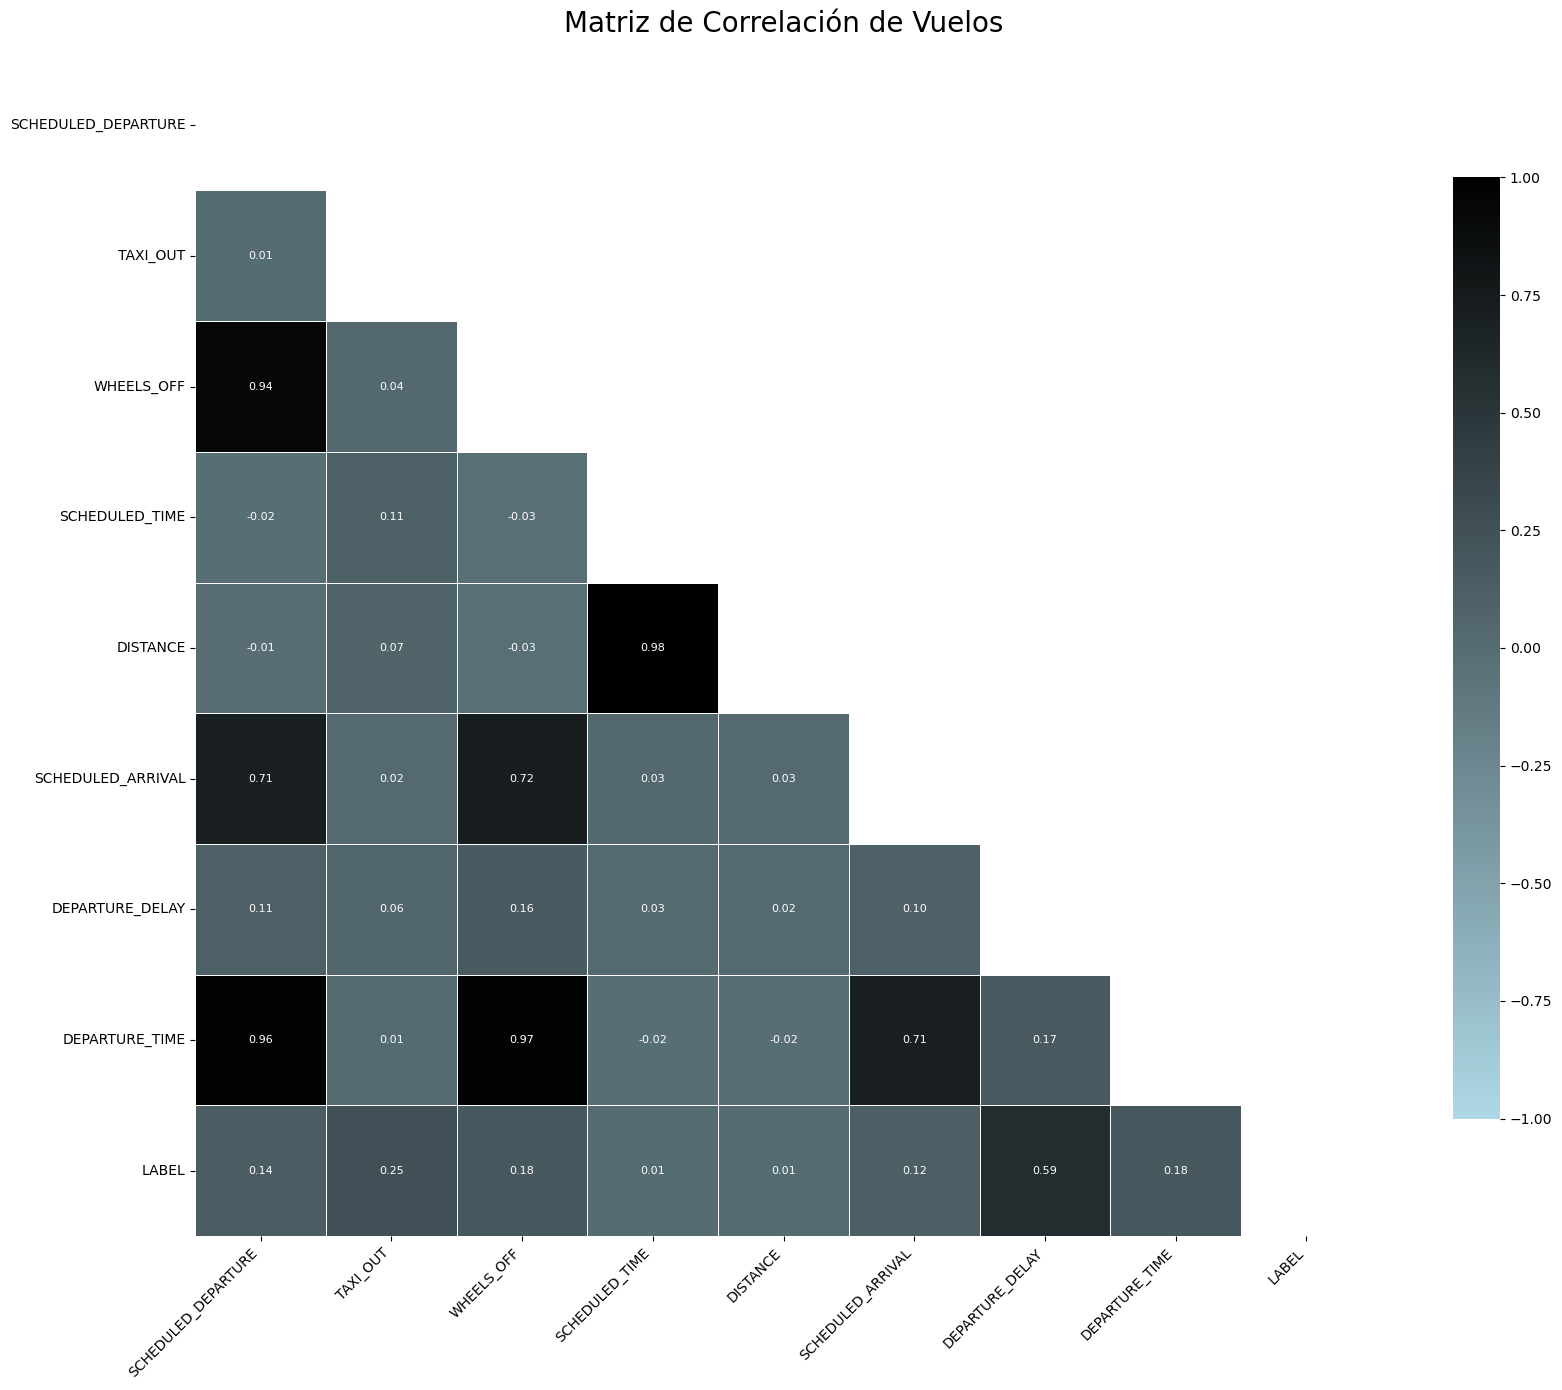

In [80]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Seleccionamos las variables numéricas candidatas
numeric_cols = [
    "SCHEDULED_DEPARTURE", "TAXI_OUT", "WHEELS_OFF", "SCHEDULED_TIME",
    "DISTANCE", "SCHEDULED_ARRIVAL", "DEPARTURE_DELAY", "DEPARTURE_TIME", "LABEL"
]

categorical_cols = ["AIRLINE", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"] 

# 2. Preparamos el vector para Spark
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="corr_features")
df_vector = assembler.transform(df_model).select("corr_features")

# 3. Calculamos la matriz de Pearson
matrix = Correlation.corr(df_vector, "corr_features").collect()[0][0]
cor_np = matrix.toArray()

# 4. Lo pasamos a un DataFrame de Pandas
corr_matrix_df = pd.DataFrame(cor_np, columns=numeric_cols, index=numeric_cols)

# --- NUEVO CÓDIGO: MAPA DE CALOR TRIANGULAR ---

# 5. Generar una máscara para el triángulo superior
# Esto crea una matriz de booleanos donde el triángulo superior es True (y por tanto, se ocultará)
mask = np.triu(np.ones_like(corr_matrix_df, dtype=bool))

# 6. Configurar el tamaño de la figura
plt.figure(figsize=(18, 14))

# 7. Crear el mapa de colores personalizado: de azul claro ('#ADD8E6') a negro ('#000000')
cmap = LinearSegmentedColormap.from_list("light_blue_to_black", ["#ADD8E6", "#000000"])

# 8. Dibujar el mapa de calor
sns.heatmap(corr_matrix_df, 
            mask=mask, 
            cmap=cmap, 
            vmin=-1.0, vmax=1.0,       # El rango de correlación de Pearson es siempre -1 a 1
            center=0,                  # Centramos el color en 0 (sin correlación)
            square=True,               # Forzamos que las celdas sean cuadradas
            linewidths=0.5,            # Líneas de separación finas entre celdas
            cbar_kws={"shrink": 0.8},  # Ajustamos el tamaño de la barra de leyenda
            annot=True,                # Mostramos los valores numéricos
            fmt=".2f",                 # Redondeamos a 2 decimales
            annot_kws={"size": 8})     # Reducimos un poco el texto para que quepa bien

# 9. Ajustes finales de diseño
plt.title("Matriz de Correlación de Vuelos", fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right')    # Inclinamos las etiquetas del eje X para que no se superpongan
plt.yticks(rotation=0)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

Independientemente del escenario anterior, hay variables redundantes que dicen exactamente lo mismo. 

- El gemelo de la Distancia (0.98): DISTANCE y SCHEDULED_TIME son la misma variable disfrazada.

Nos quedamos con: DISTANCE (es un dato físico inmutable).

- El gemelo de los Horarios (>0.94): SCHEDULED_DEPARTURE, WHEELS_OFF y DEPARTURE_TIME están todas correlacionadas casi al 100%.

Nos quedamos con: SCHEDULED_DEPARTURE (es la métrica base y planificada).


## 3.5 Análisis de Correlación con LABEL - Variables Categóricas

Como las variables categóricas podrían tener muchas categorías como por ejemplo, TAIL_NUMBER, que es la matrícula del avión o FLIGHT_NUMBER, el número de vuelo, no podríamos resumir estas variables con categorías, procedemos a agrupar por cada cada variables categórico como ORIGIN_AIRPORT, y mirar que aeropuertos tienen significancia estadística en la variable respuesta.

In [81]:
impacto_aeropuerto = df_model.groupBy("ORIGIN_AIRPORT").agg(
    F.count("LABEL").alias("NUM_VUELOS"),
    F.mean("LABEL").alias("PROB_RETRASO")
)

aeropuertos_relevantes = impacto_aeropuerto.filter(impacto_aeropuerto["NUM_VUELOS"] > 100)
resultado = aeropuertos_relevantes.orderBy(F.desc("PROB_RETRASO"))
resultado.show()

+--------------+----------+-------------------+
|ORIGIN_AIRPORT|NUM_VUELOS|       PROB_RETRASO|
+--------------+----------+-------------------+
|           PBG|       278| 0.3237410071942446|
|           MMH|       140|                0.3|
|           ASE|      3263|0.29665951578302174|
|           PPG|       106|0.29245283018867924|
|           OTH|       264| 0.2727272727272727|
|           UST|       144| 0.2638888888888889|
|           BPT|       905| 0.2596685082872928|
|         11695|       156| 0.2564102564102564|
|           MVY|       205|0.24878048780487805|
|           HPN|      7132|0.24733595064498037|
|           CEC|       173|0.24277456647398843|
|           RHI|       937|0.24119530416221985|
|           ORD|    276554| 0.2410487644366019|
|           LBE|      1245|0.24016064257028114|
|           LGA|     94834|0.23946053103317375|
|           TTN|      2771|0.23782028148682785|
|           EGE|      1198| 0.2353923205342237|
|         13795|       112|0.23214285714

In [82]:
impacto_aeropuerto = df_model.groupBy("DESTINATION_AIRPORT").agg(
    F.count("LABEL").alias("NUM_VUELOS"),
    F.mean("LABEL").alias("PROB_RETRASO")
)

aeropuertos_relevantes = impacto_aeropuerto.filter(impacto_aeropuerto["NUM_VUELOS"] > 100)
resultado = aeropuertos_relevantes.orderBy(F.desc("PROB_RETRASO"))
resultado.show()

+-------------------+----------+-------------------+
|DESTINATION_AIRPORT|NUM_VUELOS|       PROB_RETRASO|
+-------------------+----------+-------------------+
|                PBG|       281| 0.3238434163701068|
|                ASE|      3260| 0.3156441717791411|
|                GUM|       331|  0.311178247734139|
|                OTH|       266| 0.3007518796992481|
|                BPT|       915|0.29617486338797816|
|                MQT|       296| 0.2939189189189189|
|                BQN|      1328| 0.2914156626506024|
|                TTN|      2761| 0.2817819630568635|
|                GUC|       470|0.27872340425531916|
|                PSE|       737|0.27408412483039346|
|                LGA|     94527| 0.2625599035196293|
|                LBE|      1247| 0.2590216519647153|
|                COU|      1256| 0.2571656050955414|
|                ACY|      3530|0.25127478753541077|
|                UST|       146| 0.2465753424657534|
|                IAG|       313|0.246006389776

In [83]:
impacto_aeropuerto = df_model.groupBy("AIRLINE_NAMES").agg(
    F.count("LABEL").alias("NUM_VUELOS"),
    F.mean("LABEL").alias("PROB_RETRASO")
)

aeropuertos_relevantes = impacto_aeropuerto.filter(impacto_aeropuerto["NUM_VUELOS"] > 100)
resultado = aeropuertos_relevantes.orderBy(F.desc("PROB_RETRASO"))
resultado.show()

+--------------------+----------+-------------------+
|       AIRLINE_NAMES|NUM_VUELOS|       PROB_RETRASO|
+--------------------+----------+-------------------+
|    Spirit Air Lines|    115193| 0.2970753431198076|
|Frontier Airlines...|     90090|0.26162726162726163|
|     JetBlue Airways|    262042|0.22582257806000564|
|American Eagle Ai...|    278791|0.21717702508330614|
|United Air Lines ...|    507762| 0.2062422946183448|
|Atlantic Southeas...|    554752| 0.1968158744808491|
|      Virgin America|     61248| 0.1923001567398119|
|Southwest Airline...|   1242403| 0.1904583295436344|
|     US Airways Inc.|    194223|0.18818059653079192|
|Skywest Airlines ...|    576814|0.18687999944522846|
|American Airlines...|    712935|0.18273615406734134|
|Delta Air Lines Inc.|    870275|0.13561575364109046|
|Alaska Airlines Inc.|    171439|0.13037873529360297|
|Hawaiian Airlines...|     76041|0.11333359634933786|
+--------------------+----------+-------------------+



## 3.6 Selección de Variables para Modelado

In [84]:
df_model_reducido = df_model.select("MONTH", "DAY_OF_WEEK", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "SCHEDULED_DEPARTURE", "DISTANCE", "SCHEDULED_ARRIVAL", "LABEL")

# 4. Modelado
## 4.1 Modelo básico


In [85]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. El Split Correcto (mantenemos X e Y juntos en el mismo DataFrame)
# Nota: Usa el mismo DataFrame en la condición del filter para evitar errores
train = df_model_reducido.filter(df_model_reducido["MONTH"] <= 10)
test = df_model_reducido.filter(df_model_reducido["MONTH"] > 10)

# 2. Definir tus variables predictoras (las que elegiste tras el análisis de correlación)
# Asegúrate de poner aquí exactamente los nombres de las columnas que vas a usar
columnas_predictoras = [
    "SCHEDULED_DEPARTURE", 
    "DISTANCE", 
    "SCHEDULED_ARRIVAL", 
    # Añade aquí tus categóricas indexadas (ej. "ORIGIN_INDEX") si las tienes
]

# 3. Ensamblar las variables en la columna "features"
assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")

# Transformamos tanto el train como el test
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# 4. Crear y entrenar el modelo (Regresión Logística)
lr = LogisticRegression(featuresCol="features", labelCol="LABEL")

print("Entrenando el modelo... (esto puede tardar unos segundos)")
modelo_lr = lr.fit(train_assembled)

# 5. Hacer predicciones con los meses 11 y 12
predicciones = modelo_lr.transform(test_assembled)

# 6. Evaluar el modelo (Usaremos el Área Bajo la Curva ROC - AUC)
# Un AUC de 0.5 es como tirar una moneda al aire. 1.0 es predicción perfecta.
evaluator = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predicciones)

print(f"--- RESULTADOS DEL MODELO ---")
print(f"Área bajo la curva ROC (AUC): {auc:.4f}")

# (Opcional) Ver las predicciones frente a la realidad
predicciones.select("LABEL", "prediction", "probability").show(5)

Entrenando el modelo... (esto puede tardar unos segundos)


--- RESULTADOS DEL MODELO ---
Área bajo la curva ROC (AUC): 0.5845


+-----+----------+--------------------+
|LABEL|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.92798998106795...|
|    0|       0.0|[0.92426101832234...|
|    0|       0.0|[0.91990858007920...|
|    0|       0.0|[0.92364702248474...|
|    0|       0.0|[0.92601958974978...|
+-----+----------+--------------------+
only showing top 5 rows



## 4.2 RandomForest

In [86]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# OPTIMIZACIÓN PREVIA: Limpiar caché y configurar Checkpoints para no saturar la RAM
spark.catalog.clearCache()
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")

# 1. El Split Correcto (mantenemos X e Y juntos en el mismo DataFrame)
# Nota: Usa el mismo DataFrame en la condición del filter para evitar errores
train = df_model_reducido.filter(df_model_reducido["MONTH"] <= 10)
test = df_model_reducido.filter(df_model_reducido["MONTH"] > 10)

# 2. Definir tus variables predictoras (las que elegiste tras el análisis de correlación)
# Asegúrate de poner aquí exactamente los nombres de las columnas que vas a usar
columnas_predictoras = [
    "SCHEDULED_DEPARTURE", 
    "DISTANCE", 
    "SCHEDULED_ARRIVAL",
    "MONTH"
    # Añade aquí tus categóricas indexadas (ej. "ORIGIN_INDEX") si las tienes
]

# 3. Ensamblar las variables en la columna "features"
assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")

# Transformamos tanto el train como el test
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# 4. Crear y entrenar el modelo (Random Forest)
# Nota: Añadimos maxBins=1000 y configuraciones de memoria para que el clúster aguante
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=10, 
    maxDepth=7, 
    maxBins=1000,          # Vital si hay muchos aeropuertos distintos
    cacheNodeIds=True,     # Optimización de memoria
    checkpointInterval=10, # Libera la RAM cada 10 iteraciones
    seed=42
)

print("Entrenando Random Forest... (esto puede tardar unos minutos)")
modelo_rf = rf.fit(train_assembled)

# 5. Hacer predicciones con los meses 11 y 12
predicciones_rf = modelo_rf.transform(test_assembled)

# 6. Evaluar el modelo (Añadimos PR AUC y Matriz de Confusión por el desbalanceo)
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print(f"--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f}")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f}")

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Entrenando Random Forest... (esto puede tardar unos minutos)


26/05/11 11:22:44 WARN MemoryStore: Not enough space to cache rdd_9758_1 in memory! (computed 99.9 MiB so far)
26/05/11 11:22:44 WARN BlockManager: Persisting block rdd_9758_1 to disk instead.
26/05/11 11:22:44 WARN MemoryStore: Not enough space to cache rdd_9758_3 in memory! (computed 99.9 MiB so far)
26/05/11 11:22:44 WARN BlockManager: Persisting block rdd_9758_3 to disk instead.
26/05/11 11:22:44 WARN MemoryStore: Not enough space to cache rdd_9758_0 in memory! (computed 99.9 MiB so far)
26/05/11 11:22:44 WARN BlockManager: Persisting block rdd_9758_0 to disk instead.
26/05/11 11:22:44 WARN MemoryStore: Not enough space to cache rdd_9758_2 in memory! (computed 99.9 MiB so far)
26/05/11 11:22:44 WARN BlockManager: Persisting block rdd_9758_2 to disk instead.
26/05/11 11:22:54 WARN MemoryStore: Not enough space to cache rdd_9758_0 in memory! (computed 99.9 MiB so far)
26/05/11 11:22:54 WARN MemoryStore: Not enough space to cache rdd_9758_0 in memory! (computed 2.3 MiB so far)
26/05/1

--- RESULTADOS RANDOM FOREST ---
Área bajo la curva ROC (AUC): 0.5855
Área bajo la curva PR (PR AUC): 0.2186

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|764741|
|    1|       0.0|167343|
+-----+----------+------+



Probamos a añadir las variables categóricas:

In [87]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# 1. Definimos las variables categóricas que queremos usar
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DAY_OF_WEEK"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

# 2. Pasamos los textos a números (StringIndexer)
indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
# Entrenamos el indexador y transformamos el DataFrame completo
df_listo = indexer.fit(df_model_reducido).transform(df_model_reducido)

# 3. El Split Correcto (usando el nuevo df_listo que ya tiene los índices)
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# 4. Actualizamos la lista de variables predictoras ¡Añadiendo las categóricas!
columnas_predictoras = [
    "SCHEDULED_DEPARTURE", 
    "DISTANCE", 
    "SCHEDULED_ARRIVAL",
    "MONTH"
] + indexed_cols # Sumamos la lista de las variables indexadas

# 5. Ensamblamos todo en la columna "features"
assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")

train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# 4. Crear y entrenar el modelo (Random Forest)
# Nota: Añadimos maxBins=1000 y configuraciones de memoria para que el clúster aguante
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=10, 
    maxDepth=7, 
    maxBins=1000,          # Vital si hay muchos aeropuertos distintos
    cacheNodeIds=True,     # Optimización de memoria
    checkpointInterval=10, # Libera la RAM cada 10 iteraciones
    seed=42
)

print("Entrenando Random Forest... (esto puede tardar unos minutos)")
modelo_rf = rf.fit(train_assembled)

# 5. Hacer predicciones con los meses 11 y 12
predicciones_rf = modelo_rf.transform(test_assembled)

# 6. Evaluar el modelo (Añadimos PR AUC y Matriz de Confusión por el desbalanceo)
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")


auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print(f"--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f}")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f}")

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Entrenando Random Forest... (esto puede tardar unos minutos)


26/05/11 11:25:37 WARN MemoryStore: Not enough space to cache rdd_9971_3 in memory! (computed 96.4 MiB so far)
26/05/11 11:25:37 WARN BlockManager: Persisting block rdd_9971_3 to disk instead.
26/05/11 11:25:37 WARN MemoryStore: Not enough space to cache rdd_9971_2 in memory! (computed 96.4 MiB so far)
26/05/11 11:25:37 WARN BlockManager: Persisting block rdd_9971_2 to disk instead.
26/05/11 11:25:37 WARN MemoryStore: Not enough space to cache rdd_9971_0 in memory! (computed 96.4 MiB so far)
26/05/11 11:25:37 WARN BlockManager: Persisting block rdd_9971_0 to disk instead.
26/05/11 11:25:48 WARN MemoryStore: Not enough space to cache rdd_9971_3 in memory! (computed 96.4 MiB so far)
26/05/11 11:25:49 WARN MemoryStore: Not enough space to cache rdd_9971_3 in memory! (computed 40.7 MiB so far)
26/05/11 11:25:49 WARN MemoryStore: Not enough space to cache rdd_9972_3 in memory! (computed 8.7 MiB so far)
26/05/11 11:25:49 WARN BlockManager: Persisting block rdd_9972_3 to disk instead.
26/05/1

--- RESULTADOS RANDOM FOREST ---
Área bajo la curva ROC (AUC): 0.5765
Área bajo la curva PR (PR AUC): 0.2151

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|764741|
|    1|       0.0|167343|
+-----+----------+------+



El modelo sigue precidiendo todo sin retraso, puede ser debido al desbalanceo de clases. Como el 81% de los vuelos llegan a tiempo, el algoritmo de Random Forest ha descubierto que la forma más "fácil" de equivocarse poco es apostar siempre al 0. Si apuesta siempre al 0, acierta el 81% de las veces. Al algoritmo le parece un trato excelente, pero para tu caso de uso es inútil. Vamo a probar equilibrando las clases.
## 4.3 RandomForest con Desbalanceo


In [88]:
import pyspark.sql.functions as F
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# =================================================================
# 1. UNDERSAMPLING: EQUILIBRAR LOS DATOS (50% Retrasos / 50% Puntuales)
# =================================================================

# Separar las clases del set de entrenamiento
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

# Contar cuántos hay de cada uno
count_0 = train_0.count()
count_1 = train_1.count()

print(f"Antes del balanceo - Puntuales: {count_0}, Retrasados: {count_1}")

# Calcular qué porcentaje de la clase 0 necesitamos para igualar a la clase 1
fraccion = count_1 / count_0

# Coger una muestra aleatoria de los vuelos puntuales para igualar la cantidad
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)

# Unir los retrasados con la muestra reducida de puntuales
train_balanced = train_1.union(train_0_sub)

print(f"Después del balanceo - Entrenando con {train_balanced.count()} vuelos en total (50/50)\n")

# =================================================================
# 2. ENTRENAMIENTO DEL RANDOM FOREST (Con datos equilibrados)
# =================================================================

rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=10,           # Bajamos temporalmente a 10 árboles para asegurar que termina
    maxDepth=6,            # Reducimos profundidad para salvar la memoria Heap de Java
    maxBins=700,           # 400 es suficiente para cubrir los ~350 aeropuertos (1000 era excesivo)
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Random Forest balanceado y optimizado en memoria...")
modelo_rf = rf.fit(train_balanced)

# =================================================================
# 3. PREDICCIÓN Y EVALUACIÓN
# =================================================================

print("Haciendo predicciones en el set de test...")
# Para predecir sí usamos el test completo original
predicciones_rf = modelo_rf.transform(test_assembled)

# Evaluar
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print("\n--- RESULTADOS RANDOM FOREST BALANCEADO ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f}")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f}")

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Antes del balanceo - Puntuales: 3885828, Retrasados: 896096


Después del balanceo - Entrenando con 1793870 vuelos en total (50/50)

Entrenando Random Forest balanceado y optimizado en memoria...


Haciendo predicciones en el set de test...



--- RESULTADOS RANDOM FOREST BALANCEADO ---
Área bajo la curva ROC (AUC): 0.5771
Área bajo la curva PR (PR AUC): 0.2119

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|694755|
|    0|       1.0| 69986|
|    1|       0.0|148140|
|    1|       1.0| 19203|
+-----+----------+------+



El análisis del modelo de Random Forest balanceado revela una capacidad predictiva global limitada, evidenciada por un Área Bajo la Curva ROC (AUC) de 0.5771 y un PR AUC de 0.2119. Aunque la técnica de submuestreo (undersampling) logró corregir la polarización del modelo inicial —permitiendo identificar correctamente 19.203 casos de retraso (Verdaderos Positivos)—, el alto volumen de Falsos Negativos (148.140) indica que el modelo tiene dificultades para generalizar. Esta limitación no se debe a una falla algorítmica, sino a la naturaleza estática de las variables predictoras disponibles en este escenario de predicción temprana. Factores exógenos críticos que determinan la puntualidad operativa, como las condiciones meteorológicas puntuales, la saturación del tráfico aéreo diario o el efecto dominó provocado por el retraso de la aeronave en rutas previas (late aircraft delay), no están presentes en la entrada del modelo. Al basar sus decisiones únicamente en la distancia, el mes y los horarios estandarizados programados, el algoritmo carece del contexto dinámico necesario para aislar con alta precisión los vuelos propensos a demoras.

## 4.4 RandomForest - Añadir Variables con Poder Predictivo 
### Hora de Salida con el Horario Previsto de Salida y IS_WEEKEN con DAY_OF_THE_WEEK


In [89]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

print("1. Creando nuevas variables predictoras (Feature Engineering)...")

# Extraer la HORA exacta de salida y FIN DE SEMANA
df_features = df_model.withColumn("DEPARTURE_HOUR", (F.col("SCHEDULED_DEPARTURE") / 100).cast(IntegerType()))
df_features = df_features.withColumn("IS_WEEKEND", F.when(F.col("DAY_OF_WEEK").isin([6, 7]), 1).otherwise(0))

# Seleccionamos SIN la variable ROUTE
df_model_reducido = df_features.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", 
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", 
    "AIRLINE_NAMES", "DISTANCE", "LABEL"
)

print("2. Indexando variables categóricas...")
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_model_reducido).transform(df_model_reducido)

print("3. Haciendo el split temporal y ensamblando...")
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

columnas_predictoras = [
    "DISTANCE", 
    "MONTH",
    "IS_WEEKEND",
    "DEPARTURE_HOUR"
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

print("4. Aplicando Undersampling (50/50)...")
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

print("5. Entrenando Random Forest...")
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=15,           
    maxDepth=6,            
    maxBins=700,  # <-- 700 es perfecto para los ~630 aeropuertos y no colapsa la RAM
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)
modelo_rf = rf.fit(train_balanced)

print("6. Evaluando el modelo...")
predicciones_rf = modelo_rf.transform(test_assembled)

evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

auc_roc_rf = evaluator_roc.evaluate(predicciones_rf)
auc_pr_rf = evaluator_pr.evaluate(predicciones_rf)

print("\n" + "="*45)
print("--- RESULTADOS FINALES ---")
print(f"Área bajo la curva ROC (AUC): {auc_roc_rf:.4f} (El anterior era 0.5771)")
print(f"Área bajo la curva PR (PR AUC): {auc_pr_rf:.4f} (El anterior era 0.2119)")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

1. Creando nuevas variables predictoras (Feature Engineering)...
2. Indexando variables categóricas...


3. Haciendo el split temporal y ensamblando...
4. Aplicando Undersampling (50/50)...


5. Entrenando Random Forest...


6. Evaluando el modelo...



--- RESULTADOS FINALES ---
Área bajo la curva ROC (AUC): 0.5971 (El anterior era 0.5771)
Área bajo la curva PR (PR AUC): 0.2349 (El anterior era 0.2119)

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|760944|
|    0|       1.0|  3797|
|    1|       0.0|165314|
|    1|       1.0|  2029|
+-----+----------+------+



La aplicación de Ingeniería de Variables (extracción de la franja horaria y factor de fin de semana) logró incrementar el poder predictivo global del modelo, elevando el AUC ROC a 0.5971. No obstante, al evaluar la matriz de confusión, se observa que el Random Forest adoptó un sesgo conservador. Redujo drásticamente la tasa de Falsos Positivos a costa de sacrificar la sensibilidad (Recall), identificando únicamente los retrasos con mayor certidumbre estadística. Este comportamiento confirma que, ante la ausencia de variables dinámicas operativas (clima, tráfico en tiempo real), los árboles de decisión priorizan la precisión sobre la exhaustividad en este conjunto de datos.

## 4.4 Random Forest - Mejora mediante la Integración de Datos Meteorológicos 

Hasta este punto, nuestro modelo predictivo ha dependido exclusivamente de variables logísticas estáticas, como la franja horaria, el día de la semana o la distancia del trayecto. Sin embargo, en la aviación comercial, las disrupciones operativas están intrínsecamente ligadas a las condiciones ambientales. Para dotar al algoritmo de este contexto y superar el límite predictivo actual, hemos decidido integrar información meteorológica histórica correspondiente al año 2015.

Para evitar la maldición de la dimensionalidad y no sobrecargar la memoria de nuestro clúster Spark, no utilizaremos todas las métricas climáticas disponibles, sino que hemos seleccionado los tres conjuntos de datos más críticos para la operativa aeroportuaria:

* **Velocidad del viento (`wind_speed.csv`):** Las rachas de viento cruzado limitan el uso de ciertas pistas, reduciendo la capacidad operativa de los aeropuertos y generando congestión en el espacio aéreo.
* **Temperatura (`temperature.csv`):** Las temperaturas extremas tienen un impacto directo. El calor extremo reduce la densidad del aire (limitando el peso al despegue), mientras que las temperaturas gélidas obligan a aplicar protocolos de *de-icing* (descongelación de alas), lo que añade demoras fijas muy significativas antes del despegue. Los datos originales vienen en grados Kelvin, por lo que aplicaremos una transformación a grados Celsius para facilitar su interpretabilidad.
* **Condiciones meteorológicas (`weather_description.csv`):** Este dataset contiene descripciones en formato de texto (como "light rain" o "thunderstorm"). Mediante expresiones regulares (RegEx), extraeremos las palabras clave que denotan peligro y transformaremos esta información en una variable binaria (`BAD_WEATHER`), la cual actuará como una bandera de riesgo para el modelo.


### 4.4.1 Unir los 3 CSVs (Temperature, Wind y DescriptionWeather)
#### Temperature - Pasar de Kelvin a Celsius y unir Ciudad con IATA Code
#### Wind - unir Ciudad con IATA Code
#### Weather - poner los valores de la tabla como variables (Mist, Few Clouds, sky is clear, scattered clouds, haze...), unir Ciudad con IATA Code y poner un 1 en la variable que tiene valor el resgistro






In [90]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

# Mapeo Maestro: Ciudad -> IATA -> Zona Horaria (Formato oficial IANA para Spark)
weather_mapping = [
    ("New York", "JFK", "America/New_York"), ("New York", "LGA", "America/New_York"), ("New York", "EWR", "America/New_York"),
    ("Boston", "BOS", "America/New_York"), ("Philadelphia", "PHL", "America/New_York"), 
    ("Atlanta", "ATL", "America/New_York"), ("Miami", "MIA", "America/New_York"), 
    ("Detroit", "DTW", "America/Detroit"),
    ("Chicago", "ORD", "America/Chicago"), ("Chicago", "MDW", "America/Chicago"), 
    ("Dallas", "DFW", "America/Chicago"), ("Dallas", "DAL", "America/Chicago"), 
    ("Houston", "IAH", "America/Chicago"), ("Houston", "HOU", "America/Chicago"),
    ("San Antonio", "SAT", "America/Chicago"),
    ("Denver", "DEN", "America/Denver"), ("Phoenix", "PHX", "America/Phoenix"),
    ("Los Angeles", "LAX", "America/Los_Angeles"), ("San Diego", "SAN", "America/Los_Angeles"), 
    ("Las Vegas", "LAS", "America/Los_Angeles")
]
df_mapping = spark.createDataFrame(weather_mapping, ["City", "IATA", "Timezone"])
ciudades_unicas = list(set([row[0] for row in weather_mapping]))


# Función Unpivot para reestructurar el dataset a formato largo (año 2015)
def unpivot_weather(df, value_col_name):
    df = df.withColumn("datetime", F.to_timestamp("datetime"))
    df_2015 = df.filter(F.year("datetime") == 2015)
    unpivot_expr = f"stack({len(ciudades_unicas)}, " + ", ".join([f"'{c}', `{c}`" for c in ciudades_unicas]) + f") as (City, {value_col_name})"
    return df_2015.select("datetime", F.expr(unpivot_expr))

# Unir y transformar variables climáticas
df_weather_full = unpivot_weather(df_wind, "Wind_Speed") \
    .join(unpivot_weather(df_temp, "Temperature_K"), ["datetime", "City"], "inner") \
    .join(unpivot_weather(df_desc, "Description"), ["datetime", "City"], "inner")

# Ingeniería de variables: Kelvin a Celsius y Bandera de Mal Clima
df_weather_full = df_weather_full.withColumn("Temperature_C", F.col("Temperature_K") - 273.15)
palabras_riesgo = "snow|storm|thunder|heavy|fog|mist|rain"
df_weather_full = df_weather_full.withColumn("BAD_WEATHER", F.when(F.lower(F.col("Description")).rlike(palabras_riesgo), 1).otherwise(0))

### 4.4.2 Ajuste de las Zonas Horarias. 2 ciudades tienen zonas horarias diferentes


Además, la integración de datos provenientes de distintas fuentes suele presentar desafíos ocultos que pueden arruinar el poder predictivo del modelo. Tras un análisis minucioso, hemos identificado y resuelto dos problemas críticos en nuestra arquitectura de datos:

El primer gran desafío ha sido la **Sincronización de las Zonas Horarias**. El dataset meteorológico registra los eventos en formato UTC (Tiempo Universal Coordinado), mientras que los horarios de salida de los vuelos están en la hora local del aeropuerto de origen. Si cruzáramos los datos directamente, emparejaríamos el despegue de un vuelo con un clima desfasado varias horas, destruyendo cualquier correlación matemática. Para solucionarlo, hemos implementado una transformación utilizando la función `from_utc_timestamp` de Spark, la cual ajusta automáticamente la hora UTC a la franja horaria específica de cada aeropuerto, teniendo en cuenta incluso los cambios de horario de verano e invierno (DST).

El segundo desafío radica en la **Calidad de los Datos frente a la Cantidad**. Para evitar introducir "ruido" en el modelo rellenando con ceros y valores artificiales el clima de aquellos pequeños aeropuertos regionales de los que no poseemos sensores meteorológicos, hemos optado por realizar un *Inner Join*. Esta decisión de diseño reduce el volumen total de vuelos, pero garantiza que el algoritmo se entrene exclusivamente con información de altísima fidelidad, focalizando sus esfuerzos en los grandes *hubs* (centros de conexión) nacionales donde el tráfico y el clima interactúan con mayor severidad.

In [91]:
# Asignar Aeropuerto y Convertir UTC a Hora Local de forma dinámica
df_weather = df_weather_full.join(F.broadcast(df_mapping), "City", "inner")

# Transformación clave: Ajuste de Zona Horaria
df_weather = df_weather.withColumn("local_weather_datetime", F.from_utc_timestamp(F.col("datetime"), F.col("Timezone")))

df_weather = df_weather.select(
    F.col("local_weather_datetime").alias("weather_datetime"), 
    F.col("IATA").alias("WEATHER_IATA"), 
    F.col("Wind_Speed").cast("double"), 
    F.col("Temperature_C").cast("double"), 
    F.col("BAD_WEATHER").cast("integer")
).dropna()

# Recuperar columnas del Feature Engineering previo si fuese necesario
df_model = df_model.withColumn("DEPARTURE_HOUR", (F.col("SCHEDULED_DEPARTURE") / 100).cast(IntegerType()))
df_model = df_model.withColumn("IS_WEEKEND", F.when(F.col("DAY_OF_WEEK").isin([6, 7]), 1).otherwise(0))

# Creación de Timestamp de Vuelo robusto para Spark 3.0+ (Relleno con ceros a la izquierda)
df_model = df_model.withColumn("flight_datetime", F.to_timestamp(
    F.concat_ws("-", 
                F.col("YEAR"), 
                F.lpad(F.col("MONTH").cast("string"), 2, "0"), 
                F.lpad(F.col("DAY").cast("string"), 2, "0"), 
                F.lpad(F.col("DEPARTURE_HOUR").cast("string"), 2, "0")
               ), 
    "yyyy-MM-dd-HH"
))

# Cruce de Datos mediante INNER JOIN para maximizar la pureza del dataset
df_unified = df_model.join(
    df_weather,
    (df_model["ORIGIN_AIRPORT"] == df_weather["WEATHER_IATA"]) & (df_model["flight_datetime"] == df_weather["weather_datetime"]),
    "inner" 
)

df_model_reducido = df_unified.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DISTANCE", 
    "Wind_Speed", "Temperature_C", "BAD_WEATHER", "LABEL"
)

print(f"Total de registros de alta calidad para entrenar: {df_model_reducido.count():,}")

Total de registros de alta calidad para entrenar: 2,576,764


Con nuestro conjunto de datos purificado y enriquecido, iniciamos la canalización de *Machine Learning*. Primeramente, vectorizamos las variables categóricas. Posteriormente, dividimos el dataset aplicando una partición temporal (meses 1 a 10 para Entrenamiento y meses 11 a 12 para Prueba). Esta separación respeta el orden cronológico real, evitando que el modelo "vea el futuro" durante su fase de aprendizaje.

Por último, dado el desbalanceo natural entre vuelos puntuales y demorados, aplicamos una técnica de *Undersampling*, extrayendo una muestra aleatoria de la clase mayoritaria hasta lograr una proporción simétrica del 50/50. Esto impide que los algoritmos se acomoden en predecir sistemáticamente que ningún vuelo se retrasa.

In [92]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Indexación
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_model_reducido).transform(df_model_reducido)

# Split Temporal
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# Ensamblado de Vectores
columnas_predictoras = [
    "DISTANCE", "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR",
    "Wind_Speed", "Temperature_C", "BAD_WEATHER"
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# Balanceo de Clases (Undersampling)
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

# Definición de Evaluadores globales
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")


Procederemos a evaluar el comportamiento de los datos climáticos a través de tres arquitecturas diferentes: un modelo lineal de referencia y dos algoritmos de ensamblado basados en árboles de decisión. (como se ha realizado anteriormente)

# 5. Modelado

## 5.1 Regresión Logística (Modelo Base)
Iniciamos la evaluación con un modelo lineal clásico. Su propósito principal es actuar como nuestra línea base (*baseline*), permitiéndonos observar si existe una relación matemática directa y proporcional entre el incremento de las variables climáticas (como la velocidad del viento) y la probabilidad de sufrir un retraso.

In [93]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="LABEL")
modelo_lr = lr.fit(train_balanced)
predicciones_lr = modelo_lr.transform(test_assembled)

print("="*45)
print("--- RESULTADOS REGRESIÓN LOGÍSTICA ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_lr):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_lr):.4f}")
print("="*45)

--- RESULTADOS REGRESIÓN LOGÍSTICA ---


[410597,071s][warning][gc,alloc] broadcast-exchange-793: Retried waiting for GCLocker too often allocating 524288 words


26/05/11 11:38:16 WARN TaskMemoryManager: Failed to allocate a page (4194288 bytes), try again.


Área bajo la curva ROC (AUC): 0.6190


Área bajo la curva PR (PR AUC): 0.2727


## 5.2 Random Forest Classifier
Este algoritmo implementa un enfoque de entrenamiento en paralelo (*Bagging*). Al contar ahora con variables climáticas depuradas, esperamos que las múltiples ramas de los árboles de decisión sean capaces de identificar umbrales críticos (por ejemplo, temperaturas inferiores a cero grados en aeropuertos específicos) que desencadenan cuellos de botella en la operativa logística.

In [94]:
from pyspark.ml.classification import RandomForestClassifier

# Limpieza preventiva para Spark
spark.catalog.clearCache()
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")

rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=15,           
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Random Forest balanceado...")
modelo_rf = rf.fit(train_balanced)
predicciones_rf = modelo_rf.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_rf):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_rf):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_rf.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

Entrenando Random Forest balanceado...



--- RESULTADOS RANDOM FOREST ---


Área bajo la curva ROC (AUC): 0.6304


Área bajo la curva PR (PR AUC): 0.2856

Matriz de Confusión (0=A tiempo, 1=Retraso):


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|332173|
|    0|       1.0| 35773|
|    1|       0.0| 67127|
|    1|       1.0| 18970|
+-----+----------+------+



## 5.3 Árboles Potenciados por Gradiente (Gradient-Boosted Trees)
A diferencia del paralelismo del Random Forest, el GBT utiliza una arquitectura de *Boosting*, entrenando los árboles de manera secuencial. Cada nuevo árbol dedica sus recursos a corregir exclusivamente los errores cometidos por la iteración anterior. Confiamos en que este modelo sea el más apto para modelar las interacciones complejas y no lineales, extrayendo el máximo rendimiento a la combinación de congestión aeroportuaria y disrupción ambiental.

In [95]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Gradient-Boosted Trees...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia de Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f"{name}: {imp:.4f}")

Entrenando Gradient-Boosted Trees...
[410868,163s][warning][gc,alloc] broadcast-exchange-853: Retried waiting for GCLocker too often allocating 1048578 words


26/05/11 11:42:48 WARN TaskMemoryManager: Failed to allocate a page (8388608 bytes), try again.



--- RESULTADOS FINALES GBT ---


26/05/11 11:45:59 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva ROC (AUC): 0.6367


26/05/11 11:46:30 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva PR (PR AUC): 0.2914

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 11:47:01 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|320984|
|    0|       1.0| 46962|
|    1|       0.0| 63098|
|    1|       1.0| 22999|
+-----+----------+------+


Importancia de Variables (Feature Importance):
DISTANCE: 0.0058
MONTH: 0.1234
IS_WEEKEND: 0.0241
DEPARTURE_HOUR: 0.1159
Wind_Speed: 0.0314
Temperature_C: 0.1000
BAD_WEATHER: 0.0637
ORIGIN_AIRPORT_INDEX: 0.1467
DESTINATION_AIRPORT_INDEX: 0.2808
AIRLINE_NAMES_INDEX: 0.1082


26/05/11 11:47:06 WARN DAGScheduler: Broadcasting large task binary with size 1099.6 KiB


## 5.4 GBTClassifier

In [96]:
from pyspark.ml.classification import GBTClassifier

# Limpieza de memoria previa
spark.catalog.clearCache()

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Árboles Potenciados por Gradiente (GBT)...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia Predictiva de las Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f" - {name}: {imp:.4f}")

Entrenando Árboles Potenciados por Gradiente (GBT)...



--- RESULTADOS FINALES GBT ---


26/05/11 11:50:12 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva ROC (AUC): 0.6367


26/05/11 11:50:42 WARN DAGScheduler: Broadcasting large task binary with size 1104.6 KiB


Área bajo la curva PR (PR AUC): 0.2914

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 11:51:11 WARN DAGScheduler: Broadcasting large task binary with size 1115.7 KiB
26/05/11 11:51:15 WARN DAGScheduler: Broadcasting large task binary with size 1099.6 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|320984|
|    0|       1.0| 46962|
|    1|       0.0| 63098|
|    1|       1.0| 22999|
+-----+----------+------+


Importancia Predictiva de las Variables (Feature Importance):
 - DISTANCE: 0.0058
 - MONTH: 0.1234
 - IS_WEEKEND: 0.0241
 - DEPARTURE_HOUR: 0.1159
 - Wind_Speed: 0.0314
 - Temperature_C: 0.1000
 - BAD_WEATHER: 0.0637
 - ORIGIN_AIRPORT_INDEX: 0.1467
 - DESTINATION_AIRPORT_INDEX: 0.2808
 - AIRLINE_NAMES_INDEX: 0.1082


# 6. Mejora mediante la obtención de una nueva variable "PREVIOUS_FLIGHT_DELAYED"

Tras haber integrado con éxito el contexto medioambiental (corrigiendo las zonas horarias para asegurar la sincronía de los eventos meteorológicos), abordamos ahora la principal causa estructural de las disrupciones en la aviación comercial: el arrastre de demoras o *Efecto Dominó*. En la logística aeroportuaria, si un avión sufre un retraso en su ruta matutina, es altamente probable que traslade esa demora a todos sus vuelos posteriores durante ese mismo día, independientemente del clima en sus siguientes destinos.

Para que el modelo pueda capturar esta dinámica operativa sin cometer "Fuga de Datos" (*Data Leakage*), no podemos utilizar variables que se calculen a posteriori (como los minutos de retraso a la llegada). En su lugar, utilizaremos la matrícula física de la aeronave (`TAIL_NUMBER`). Mediante el uso de funciones de ventana (*Window Functions*) en Spark, ordenaremos cronológicamente todos los vuelos realizados por cada avión. A partir de ahí, extraeremos el estado operativo de su vuelo inmediatamente anterior. Si el avión ya venía con retraso de su destino previo, activaremos una bandera de riesgo (`PREVIOUS_FLIGHT_DELAYED`).

In [97]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# 1. CAMBIO CLAVE: Usamos 'df_unified' (que tiene todas las columnas) en lugar de 'df_model_reducido'
df_tracking = df_unified.filter(F.col("TAIL_NUMBER").isNotNull())

# 2. Definir la Función de Ventana: Agrupamos por Avión y ordenamos por la fecha/hora del vuelo
window_tail = Window.partitionBy("TAIL_NUMBER").orderBy("flight_datetime")

# 3. Extraer la etiqueta (LABEL) del vuelo inmediatamente anterior (Lag = 1)
df_tracking = df_tracking.withColumn(
    "PREVIOUS_FLIGHT_DELAYED", 
    F.lag("LABEL", 1).over(window_tail)
)

# 4. Imputación de nulos: El primer vuelo de la jornada no tiene vuelo previo, asumimos que sale a tiempo (0)
df_tracking = df_tracking.fillna({"PREVIOUS_FLIGHT_DELAYED": 0})

# 5. AHORA SÍ consolidamos el dataset final limpio con todas nuestras variables estrella
df_final = df_tracking.select(
    "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES", "DISTANCE", 
    "Wind_Speed", "Temperature_C", "BAD_WEATHER",  # Bloque Climático
    "PREVIOUS_FLIGHT_DELAYED",                     # Bloque Operativo
    "LABEL"
)



## 6.1 Probar la nueva variable de VueloAnterior con BinaryClassificationEvaluator
Con nuestro conjunto de datos enriquecido en su máxima expresión, procedemos a la fase de preparación para el modelado predictivo. En primer lugar, los algoritmos de la biblioteca MLlib requieren que las variables categóricas (como la aerolínea o los aeropuertos) se transformen a un formato numérico, tarea que delegamos en un `StringIndexer`. Posteriormente, unificamos todas las características en un vector denso mediante `VectorAssembler`.

Es fundamental garantizar que la evaluación simule un entorno real. Por ello, aplicamos una partición estrictamente cronológica: utilizamos los diez primeros meses para el entrenamiento y reservamos noviembre y diciembre para validación.

Finalmente, para abordar el severo desbalanceo estructural del dataset, aplicamos una técnica de *Undersampling*. Extraemos una submuestra aleatoria de la clase mayoritaria (vuelos puntuales) hasta igualarla con la minoritaria. Esta estrategia fuerza a los algoritmos a prestar atención matemática a los retrasos, evitando un sesgo conservador.

In [98]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Transformación de variables categóricas a numéricas
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE_NAMES"]
indexed_cols = [c + "_INDEX" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=indexed_cols, handleInvalid="keep")
df_listo = indexer.fit(df_final).transform(df_final)

# División temporal (Train/Test Split cronológico)
train = df_listo.filter(df_listo["MONTH"] <= 10)
test = df_listo.filter(df_listo["MONTH"] > 10)

# Ensamblado del vector de características predictoras
columnas_predictoras = [
    "DISTANCE", "MONTH", "IS_WEEKEND", "DEPARTURE_HOUR",
    "Wind_Speed", "Temperature_C", "BAD_WEATHER",
    "PREVIOUS_FLIGHT_DELAYED"
] + indexed_cols

assembler = VectorAssembler(inputCols=columnas_predictoras, outputCol="features", handleInvalid="skip")
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

# Aplicación de Undersampling (Balanceo 50/50)
train_0 = train_assembled.filter(F.col("LABEL") == 0)
train_1 = train_assembled.filter(F.col("LABEL") == 1)

fraccion = train_1.count() / train_0.count()
train_0_sub = train_0.sample(withReplacement=False, fraction=fraccion, seed=42)
train_balanced = train_1.union(train_0_sub)

# Inicialización de evaluadores
evaluator_roc = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_pr = BinaryClassificationEvaluator(labelCol="LABEL", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

## 6.2 Probar la nueva variable de VueloAnterior con LogisticRegression
Para cuantificar el impacto del *Feature Engineering* realizado, evaluaremos tres arquitecturas algorítmicas diferentes. El objetivo es comprobar qué modelo logra capitalizar mejor la sinergia entre el clima adverso y el estado de la aeronave.

In [99]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="LABEL")
modelo_lr = lr.fit(train_balanced)
predicciones_lr = modelo_lr.transform(test_assembled)

print("="*45)
print("--- RESULTADOS REGRESIÓN LOGÍSTICA ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_lr):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_lr):.4f}")
print("="*45)

--- RESULTADOS REGRESIÓN LOGÍSTICA ---


Área bajo la curva ROC (AUC): 0.6835


Área bajo la curva PR (PR AUC): 0.3752


## 6.3 Probar la nueva variable de VueloAnterior con RandomForest

In [100]:
from pyspark.ml.classification import RandomForestClassifier

# Optimización preventiva: Limpieza de caché
spark.catalog.clearCache()
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")

rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    numTrees=15,           
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Bosque Aleatorio balanceado...")
modelo_rf = rf.fit(train_balanced)
predicciones_rf = modelo_rf.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS RANDOM FOREST ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_rf):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_rf):.4f}")
print("="*45)

Entrenando Bosque Aleatorio balanceado...



--- RESULTADOS RANDOM FOREST ---


Área bajo la curva ROC (AUC): 0.6920


Área bajo la curva PR (PR AUC): 0.3899


## 6.4 Probar la nueva variable de VueloAnterior con GBTClassifier

In [101]:
from pyspark.ml.classification import GBTClassifier

spark.catalog.clearCache()

gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="LABEL", 
    maxIter=20,            
    maxDepth=6,            
    maxBins=700,           
    cacheNodeIds=True,     
    checkpointInterval=10, 
    seed=42
)

print("Entrenando Árboles Potenciados por Gradiente (GBT)...")
modelo_gbt = gbt.fit(train_balanced)
predicciones_gbt = modelo_gbt.transform(test_assembled)

print("\n" + "="*45)
print("--- RESULTADOS FINALES GBT ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_gbt):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_gbt):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_gbt.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

print("\nImportancia Predictiva de las Variables (Feature Importance):")
for name, imp in zip(columnas_predictoras, modelo_gbt.featureImportances):
    print(f" - {name}: {imp:.4f}")

Entrenando Árboles Potenciados por Gradiente (GBT)...



--- RESULTADOS FINALES GBT ---


26/05/11 12:05:24 WARN DAGScheduler: Broadcasting large task binary with size 1132.4 KiB


Área bajo la curva ROC (AUC): 0.7025


26/05/11 12:05:54 WARN DAGScheduler: Broadcasting large task binary with size 1132.4 KiB


Área bajo la curva PR (PR AUC): 0.3959

Matriz de Confusión (0=A tiempo, 1=Retraso):


26/05/11 12:06:25 WARN DAGScheduler: Broadcasting large task binary with size 1143.4 KiB


+-----+----------+------+
|LABEL|prediction| count|
+-----+----------+------+
|    0|       0.0|312577|
|    0|       1.0| 55369|
|    1|       0.0| 48370|
|    1|       1.0| 37727|
+-----+----------+------+


Importancia Predictiva de las Variables (Feature Importance):
 - DISTANCE: 0.0057
 - MONTH: 0.0980
 - IS_WEEKEND: 0.0179
 - DEPARTURE_HOUR: 0.1144
 - Wind_Speed: 0.0269
 - Temperature_C: 0.0882
 - BAD_WEATHER: 0.0451
 - PREVIOUS_FLIGHT_DELAYED: 0.1318
 - ORIGIN_AIRPORT_INDEX: 0.1291
 - DESTINATION_AIRPORT_INDEX: 0.2662
 - AIRLINE_NAMES_INDEX: 0.0766


26/05/11 12:06:31 WARN DAGScheduler: Broadcasting large task binary with size 1124.3 KiB


## VALIDACIÓN CRUZADA

In [102]:
train_balanced.head(5)

[Row(MONTH=7, IS_WEEKEND=1, DEPARTURE_HOUR=21, ORIGIN_AIRPORT='DEN', DESTINATION_AIRPORT='OAK', AIRLINE_NAMES='Southwest Airlines Co.', DISTANCE=957, Wind_Speed=3.0, Temperature_C=19.650000000000034, BAD_WEATHER=0, PREVIOUS_FLIGHT_DELAYED=0, LABEL=1, ORIGIN_AIRPORT_INDEX=3.0, DESTINATION_AIRPORT_INDEX=41.0, AIRLINE_NAMES_INDEX=0.0, features=DenseVector([957.0, 7.0, 1.0, 21.0, 3.0, 19.65, 0.0, 0.0, 3.0, 41.0, 0.0])),
 Row(MONTH=7, IS_WEEKEND=0, DEPARTURE_HOUR=17, ORIGIN_AIRPORT='DEN', DESTINATION_AIRPORT='MSP', AIRLINE_NAMES='Southwest Airlines Co.', DISTANCE=680, Wind_Speed=7.0, Temperature_C=20.840000000000032, BAD_WEATHER=1, PREVIOUS_FLIGHT_DELAYED=0, LABEL=1, ORIGIN_AIRPORT_INDEX=3.0, DESTINATION_AIRPORT_INDEX=13.0, AIRLINE_NAMES_INDEX=0.0, features=DenseVector([680.0, 7.0, 0.0, 17.0, 7.0, 20.84, 1.0, 0.0, 3.0, 13.0, 0.0])),
 Row(MONTH=7, IS_WEEKEND=0, DEPARTURE_HOUR=22, ORIGIN_AIRPORT='DEN', DESTINATION_AIRPORT='GEG', AIRLINE_NAMES='Southwest Airlines Co.', DISTANCE=836, Wind_Speed

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

print("--- 3.1. Ajuste de Hiperparámetros Avanzado (CrossValidator con GBT) ---")

# Construimos la malla de parámetros usando tu objeto 'gbt'
# Se añaden stepSize (Learning Rate) y minInstancesPerNode (control de sobreajuste)
paramGrid_gbt = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [4, 6]) \
    .addGrid(gbt.maxIter, [10, 20]) \
    .addGrid(gbt.stepSize, [0.05, 0.1]) \
    .addGrid(gbt.minInstancesPerNode, [1, 5]) \
    .build()

# Configuramos el validador cruzado (K-Fold = 3)
crossval_gbt = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=evaluator_roc, # Asume que tu evaluador ya está instanciado
    numFolds=3,
    seed=42
)

# Avisamos del volumen de entrenamiento (2x2x2x2 = 16 combinaciones * 3 folds = 48 entrenamientos)
print(f"Ejecutando GridSearch sobre GBT con {len(paramGrid_gbt)} combinaciones...")
print("(Advertencia: GBT es secuencial. Esto tomará un tiempo de cómputo elevado)")

# Entrenamos para buscar la mejor combinación
cv_model_gbt = crossval_gbt.fit(train_balanced)

# Extraemos el mejor modelo resultante
mejor_modelo_gbt = cv_model_gbt.bestModel

# Hacemos las predicciones sobre el set de test ensamblado
predicciones_cv_gbt = mejor_modelo_gbt.transform(test_assembled)

# Mostramos los resultados finales y los parámetros ganadores
print("\n" + "="*45)
print("--- RESULTADOS OPTIMIZACIÓN GBT ---")
print(f"Mejor AUC conseguido: {evaluator_roc.evaluate(predicciones_cv_gbt):.4f}")
print(f"Mejor parámetro 'maxDepth': {mejor_modelo_gbt.getMaxDepth()}")
print(f"Mejor parámetro 'maxIter': {mejor_modelo_gbt.getMaxIter()}")
print(f"Mejor parámetro 'stepSize': {mejor_modelo_gbt.getStepSize()}")
print(f"Mejor parámetro 'minInstancesPerNode': {mejor_modelo_gbt.getMinInstancesPerNode()}")
print("="*45)

--- 3.1. Ajuste de Hiperparámetros Avanzado (CrossValidator con GBT) ---
Ejecutando GridSearch sobre GBT con 16 combinaciones...
(Advertencia: GBT es secuencial. Esto tomará un tiempo de cómputo elevado)


26/05/11 13:50:15 WARN DAGScheduler: Broadcasting large task binary with size 1220.8 KiB
26/05/11 14:04:19 WARN DAGScheduler: Broadcasting large task binary with size 1228.9 KiB
26/05/11 14:17:16 WARN DAGScheduler: Broadcasting large task binary with size 1199.0 KiB
26/05/11 14:30:05 WARN DAGScheduler: Broadcasting large task binary with size 1199.5 KiB
26/05/11 15:56:18 WARN DAGScheduler: Broadcasting large task binary with size 1181.3 KiB
26/05/11 16:09:20 WARN DAGScheduler: Broadcasting large task binary with size 1179.8 KiB
26/05/11 16:22:06 WARN DAGScheduler: Broadcasting large task binary with size 1203.6 KiB
26/05/11 16:34:39 WARN DAGScheduler: Broadcasting large task binary with size 1200.5 KiB


In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

print("--- 3.2. Ajuste de Hiperparámetros (CrossValidator con RandomForest) ---")

# Asumimos que 'rf' ya está instanciado previamente en tu cuaderno:
# rf = RandomForestClassifier(featuresCol="features", labelCol="LABEL", seed=42)

# Construimos la malla de parámetros para Random Forest
paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [5, 7, 10]) \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.featureSubsetStrategy, ["auto", "sqrt"]) \
    .build()

# Configuramos el validador cruzado (K-Fold = 3)
crossval_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator_roc,
    numFolds=3,
    seed=42
)

# El Random Forest se entrena en paralelo, por lo que será más rápido que el GBT
print(f"Ejecutando GridSearch sobre Random Forest con {len(paramGrid_rf)} combinaciones...")

# Entrenamos para buscar la mejor combinación
cv_model_rf = crossval_rf.fit(train_balanced)

# Extraemos el mejor modelo resultante
mejor_modelo_rf = cv_model_rf.bestModel

# Hacemos las predicciones sobre el set de test ensamblado
predicciones_cv_rf = mejor_modelo_rf.transform(test_assembled)

# Mostramos los resultados finales y los parámetros ganadores
print("\n" + "="*45)
print("--- RESULTADOS OPTIMIZACIÓN RANDOM FOREST ---")
print(f"Mejor AUC conseguido: {evaluator_roc.evaluate(predicciones_cv_rf):.4f}")
print(f"Mejor parámetro 'maxDepth': {mejor_modelo_rf.getMaxDepth()}")
print(f"Mejor parámetro 'numTrees': {mejor_modelo_rf.getNumTrees()}")
print(f"Mejor parámetro 'featureSubsetStrategy': {mejor_modelo_rf.getFeatureSubsetStrategy()}")
print("="*45)

# 7. Técnicas de Mejora 
Size-Up y Speed-Up para cuando tengamos los 2-3 mejores modelos con los mejores hiperparametros (cross validation), podremos medir como se comportan ante mayor volumen de datos (size-up) o menor RAM (speed-up)

aqui intento crear una variable que mire si TAIL_NUMBER ha tenido retraso antes y probarlo con XGBoost pero no va 

In [70]:
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler

# Limpiamos caché previa por seguridad
spark.catalog.clearCache()

print("--- 1. FEATURE ENGINEERING: Efecto Arrastre (Aerolínea en Terminal) ---")

# 1.1. Ventana particionada por aerolínea y aeropuerto, ordenada en el tiempo
window_arrastre = Window.partitionBy("AIRLINE_NAMES", "ORIGIN_AIRPORT").orderBy("MONTH", "DEPARTURE_HOUR")

# 1.2. Extraemos el 'LABEL' del vuelo inmediatamente anterior (lag = 1) 
df_final = df_final.withColumn(
    "PREVIOUS_FLIGHT_DELAYED", 
    F.lag("LABEL", 1).over(window_arrastre)
)

# 1.3. Imputamos los nulos con 0.0 para el primer vuelo del día
df_final = df_final.fillna({"PREVIOUS_FLIGHT_DELAYED": 0.0})

print("Variable 'PREVIOUS_FLIGHT_DELAYED' creada con éxito en df_final.")

# ==============================================================================
# ¡ATENCIÓN A LA EJECUCIÓN LÍNEAL DE SPARK!
# Como hemos modificado 'df_final' aquí abajo, tus variables 'train_balanced' 
# y 'test_assembled' antiguas NO tienen esta nueva columna todavía.
#
# Para que la parte de abajo funcione sin dar error de "columna no encontrada", 
# debes volver a generar train y test usando el df_final actualizado.
# (Ajusta este bloque según cómo hicisteis el split originalmente)
# ==============================================================================

# Ejemplo de re-split rápido (cámbialo si usasteis un split temporal distinto):
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

# Ensamblamos las características (añadiendo la nueva)
nuevas_columnas = columnas_predictoras + ["PREVIOUS_FLIGHT_DELAYED"]
assembler_xgb = VectorAssembler(inputCols=nuevas_columnas, outputCol="features", handleInvalid="keep")

train_xgb = assembler_xgb.transform(train_data)
test_xgb  = assembler_xgb.transform(test_data)


print("\n--- 2. ENTRENAMIENTO DEL MODELO XGBOOST / GBT ---")

try:
    # Intentamos usar XGBoost si el clúster de la universidad lo tiene
    from xgboost.spark import SparkXGBClassifier
    
    xgb = SparkXGBClassifier(
        features_col="features", 
        label_col="LABEL", 
        max_depth=6,            
        n_estimators=100, 
        missing=0.0,      
        seed=42
    )
    print("Iniciando entrenamiento con XGBoost Nativo...")
    modelo_final = xgb.fit(train_xgb)

except ImportError:
    # Plan B: GBT dopado si no hay XGBoost
    print("XGBoost no está configurado. Usando GBT Avanzado como alternativa...")
    from pyspark.ml.classification import GBTClassifier
    xgb = GBTClassifier(
        featuresCol="features", 
        labelCol="LABEL", 
        maxIter=50,       
        maxDepth=7,       
        stepSize=0.05,    
        seed=42
    )
    modelo_final = xgb.fit(train_xgb)

# 3. EVALUACIÓN
predicciones_xgb = modelo_final.transform(test_xgb)

print("\n" + "="*45)
print("--- RESULTADOS FINALES CON 'PREVIOUS_FLIGHT_DELAYED' ---")
print(f"Área bajo la curva ROC (AUC): {evaluator_roc.evaluate(predicciones_xgb):.4f}")
print(f"Área bajo la curva PR (PR AUC): {evaluator_pr.evaluate(predicciones_xgb):.4f}")
print("="*45)

print("\nMatriz de Confusión (0=A tiempo, 1=Retraso):")
predicciones_xgb.groupBy("LABEL", "prediction").count().orderBy("LABEL", "prediction").show()

--- 1. FEATURE ENGINEERING: Efecto Arrastre (Aerolínea en Terminal) ---
Variable 'PREVIOUS_FLIGHT_DELAYED' creada con éxito en df_final.


IllegalArgumentException: ORIGIN_AIRPORT_INDEX does not exist. Available: MONTH, IS_WEEKEND, DEPARTURE_HOUR, ORIGIN_AIRPORT, DESTINATION_AIRPORT, AIRLINE_NAMES, DISTANCE, Wind_Speed, Temperature_C, BAD_WEATHER, PREVIOUS_FLIGHT_DELAYED, LABEL

## 7.1 Ingenieria de Variables - Window Features

In [ ]:
from pyspark.sql.window import Window

print("--- 2. Ingeniería de Variables Avanzada (Window Functions Adaptadas) ---")

# 1. Ventana de Tráfico (Saturación de pista): 
# Calculamos cuántos vuelos coinciden en el mismo aeropuerto, mes y hora.
window_trafico = Window.partitionBy("ORIGIN_AIRPORT", "MONTH", "DEPARTURE_HOUR")

# Usamos una columna descriptiva para contar el volumen de vuelos (No genera Data Leakage)
df_final = df_final.withColumn("AIRPORT_TRAFFIC", F.count(df_final["DESTINATION_AIRPORT"]).over(window_trafico))

# 2. Ventana de Historial Acumulativo: 
# Para conocer si esa ruta suele ir mal, calculamos el porcentaje histórico de retrasos 
# de esa aerolínea en ese aeropuerto. 
# Usamos 'rowsBetween' mirando hacia el pasado para evitar hacer trampas (Data Leakage).
window_historial = Window.partitionBy("AIRLINE_NAMES", "ORIGIN_AIRPORT") \
                         .orderBy("MONTH", "DEPARTURE_HOUR") \
                         .rowsBetween(Window.unboundedPreceding, -1)

# Extraemos la tasa de retrasos de los vuelos anteriores en esa partición
df_final = df_final.withColumn("HISTORICAL_DELAY_RATE", F.mean(df_final["LABEL"]).over(window_historial))

# Imputamos nulos con 0.0 para los primeros vuelos que aún no tienen datos en el historial
df_final = df_final.fillna({"HISTORICAL_DELAY_RATE": 0.0})

df_final.select("ORIGIN_AIRPORT", "AIRLINE_NAMES", "MONTH", "DEPARTURE_HOUR", "AIRPORT_TRAFFIC", "HISTORICAL_DELAY_RATE").show(5)

--- 2. Ingeniería de Variables Avanzada (Window Functions Adaptadas) ---


+--------------+--------------------+-----+--------------+---------------+---------------------+
|ORIGIN_AIRPORT|       AIRLINE_NAMES|MONTH|DEPARTURE_HOUR|AIRPORT_TRAFFIC|HISTORICAL_DELAY_RATE|
+--------------+--------------------+-----+--------------+---------------+---------------------+
|           BOS|Alaska Airlines Inc.|    1|             7|            715|                  0.0|
|           BOS|Alaska Airlines Inc.|    1|             7|            715|                  1.0|
|           BOS|Alaska Airlines Inc.|    1|             7|            715|                  0.5|
|           BOS|Alaska Airlines Inc.|    1|             7|            715|   0.6666666666666666|
|           BOS|Alaska Airlines Inc.|    1|             7|            715|                 0.75|
+--------------+--------------------+-----+--------------+---------------+---------------------+
only showing top 5 rows

